In [5]:
import pandas as pd

In [6]:
df=pd.read_csv('../data/sample_emails.csv')
df.head()

,id,sender,subject,body,priority,label
0,1,arjun.mehta@example.com,Request for EMI Clarification,"Hello Team, I need clarification regarding my ...",Medium,Query
1,2,pooja.reddy@example.com,Complaint on Processing Fee,I was charged an additional processing fee tha...,High,Complaint
2,3,rahul.sharma@example.com,Battery Warranty Concern,"Since my vehicle is an EV, I want clarity on t...",Medium,Query
3,4,neha.kapoor@example.com,Interest Rate Mismatch,The interest rate shown in the portal is diffe...,High,Dispute
4,5,vikram.singh@example.com,Request for Prepayment Information,Please share the exact charges and rules appli...,Low,Request


In [7]:
df.shape

(20, 6)

In [8]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'label'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        20 non-null     int64 
 1   sender    20 non-null     object
 2   subject   20 non-null     object
 3   body      20 non-null     object
 4   priority  20 non-null     object
 5   label     20 non-null     object
dtypes: int64(1), object(5)
memory usage: 1.1+ KB


C:\Users\muppa\AppData\Local\Temp\ipykernel_22048\2156254324.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_d", ax=axes[0, 0])
C:\Users\muppa\AppData\Local\Temp\ipykernel_22048\2156254324.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=priority_counts.index, y=priority_counts.values, palette="Reds_d", ax=axes[0, 1])
C:\Users\muppa\AppData\Local\Temp\ipykernel_22048\2156254324.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_senders.values, y=top_senders.index,

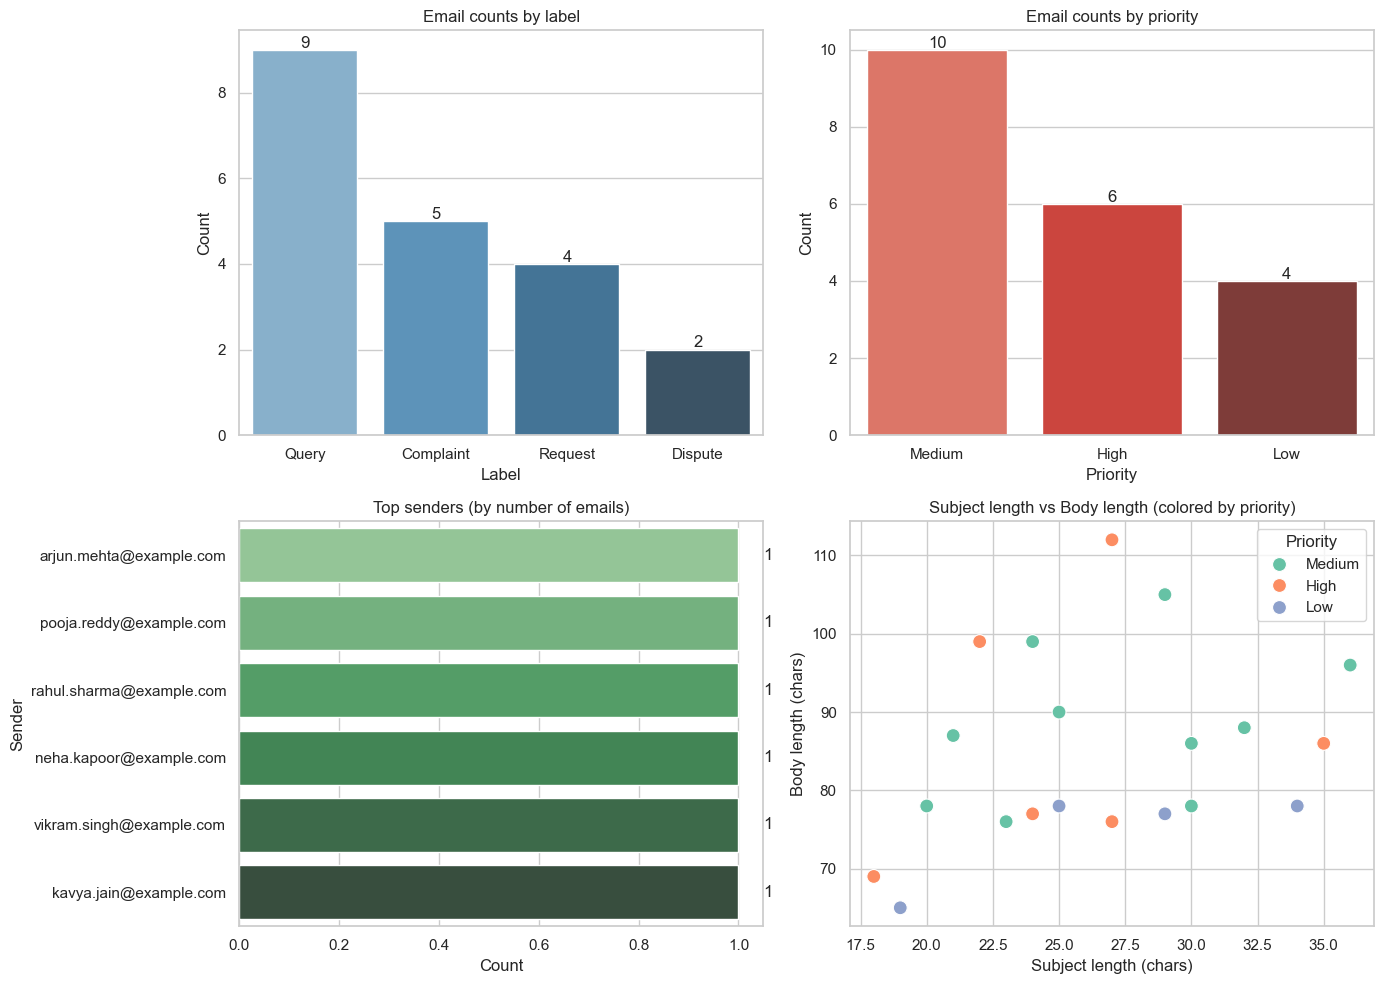


Takeaways:
- High priority emails are the most common in this sample: 0 out of 20 emails.
- The most frequent label is 'Query' with 9 emails; 'work' appears 0 time(s).
- Average body length by priority (chars):
{'High': 86.5, 'Low': 74.5, 'Medium': 88.3}
- Top senders appear to be organization addresses (HR, system, managers) which often carry 'high' priority.

Submission instructions:
- Save this notebook as: W2_assignment_<yourname>.ipynb
- Push the notebook to your own branch only.
- Commit message: "Completed Week-2 Data Analysis Assignment"


In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

# derive simple features for visualization
df['subject_len'] = df['subject'].str.len()
df['body_len'] = df['body'].str.len()

# prepare aggregates
label_counts = df['label'].value_counts()
priority_counts = df['priority'].value_counts()
top_senders = df['sender'].value_counts().nlargest(6)
avg_body_len_by_priority = df.groupby('priority')['body_len'].mean().round(1)

sns.set_theme(style="whitegrid")

# create a 2x2 figure: two bar charts, one horizontal bar for senders, one scatter
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bar chart: counts by label
sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_d", ax=axes[0, 0])
axes[0, 0].set_title("Email counts by label")
axes[0, 0].set_xlabel("Label")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0, 0].text(i, v + 0.05, str(v), ha='center')

# Bar chart: counts by priority
sns.barplot(x=priority_counts.index, y=priority_counts.values, palette="Reds_d", ax=axes[0, 1])
axes[0, 1].set_title("Email counts by priority")
axes[0, 1].set_xlabel("Priority")
axes[0, 1].set_ylabel("Count")
for i, v in enumerate(priority_counts.values):
    axes[0, 1].text(i, v + 0.05, str(v), ha='center')

# Horizontal bar: top senders
sns.barplot(x=top_senders.values, y=top_senders.index, palette="Greens_d", ax=axes[1, 0])
axes[1, 0].set_title("Top senders (by number of emails)")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("Sender")
for i, v in enumerate(top_senders.values):
    axes[1, 0].text(v + 0.05, i, str(v), va='center')

# Scatter plot (bonus analog): subject length vs body length colored by priority
sns.scatterplot(data=df, x='subject_len', y='body_len', hue='priority', s=100, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title("Subject length vs Body length (colored by priority)")
axes[1, 1].set_xlabel("Subject length (chars)")
axes[1, 1].set_ylabel("Body length (chars)")
axes[1, 1].legend(title='Priority')

plt.tight_layout()
plt.show()

# Plain-English insights / takeaways (derived from this dataset)
print("\nTakeaways:")
print(f"- High priority emails are the most common in this sample: {priority_counts.get('high',0)} out of {len(df)} emails.")
print(f"- The most frequent label is '{label_counts.idxmax()}' with {label_counts.max()} emails; 'work' appears {label_counts.get('work',0)} time(s).")
print(f"- Average body length by priority (chars):\n{avg_body_len_by_priority.to_dict()}")
print("- Top senders appear to be organization addresses (HR, system, managers) which often carry 'high' priority.")
print("\nSubmission instructions:")
print("- Save this notebook as: W2_assignment_<yourname>.ipynb")
print("- Push the notebook to your own branch only.")
print('- Commit message: "Completed Week-2 Data Analysis Assignment"')